# -1. Аннотация и результаты
---


Краткое сравнение моделей
| Модель               | R² | MAE | RMSE          | Δ RMSE к Baseline | Улучшение (%) |
| -------------------- | -- | --- | ------------- | ----------------- | ------------- |
| **Baseline (Ridge)** |    |     | **RMSE_base** | 0                 | 0             |
| Sigmoid regression   |-2.2|     |               |                   |               |
| Random Forest        |    |     |               |                   |               |
| XGBoost              |    |     |               |                   |               |
| CNN                  |    |     |               |                   |               |
| CNN + Transformer    |    |     |               |                   |               |


1. Предобработка данных
   1. Удалены дубликаты задач
   2. Обнаружены крайне странные вероятности решения для задач некоторых рейтингов (например задача с рейтингом 600 имеет вероятности решения порядка 0.003 на всех рейтингах, при чём задача несложная. Я считаю, что это уловка от авторов, чтобы люди без анализа позиции не могли победить в хакатоне)
   3. Обнаружено большое количество задач с одинаковой позицией, но разными решениями
2. Статистическая модель
   1. Было рассмотрено решение, предполагающее извлечение рейтинга задачи как рейтинг игрока, который её решает с вероятностью 50%, однако были обнаружены странные зависимости (см [7]), которые не только не могут быть проаппроксимированы сигмоидой
   2. Модель работает крайне долго из-за `curve_fit`, считается на CPU и очень неустойчива
3. Линейные модели:
   1. Обучив `LassoCV` на данных о вероятностях, выделим 6 самых главных из них, далее их и будем использовать
   2. Возьмём `RidgeCV` на этих признаках за пайплайн `R2 = 0.51 MAE = 304.0`
4. Деревья:
   1. Введём дополнительные признаки
      * Всякие комбинации вероятностей, такие как градиент от слабых к сильным игрокам, разница блиц - рапид и т.п.
      * Простейшая информация с доски, такая как число фигур
      * Длина решения
   2. Обучим `Random Forest` на 100k данных (иначе слишком долго)
5. Градиентный бустинг:
   1.  От души подобавляем признаков
      * Продвинутая статистическая информация, такая как min max вероятностей решения, средние и т.п.
      * Много информации с доски: Материал сторон, доступности рокировок, число возможных ходов
      * Информация из решения: баланс сторон после, изменения материала, наличие всяких рокировок, число шахов, матов и ещё вагончик признаков
   2. Обучим на всём этом деле `XGBoost`, получим отличную модель
6. CNN с выделенной вручную информацией из решения:
   1. Игнорируем вероятностные признаки
   2. Энкодинг партии сделаем как OneHot по фигурам, получим тензор 12x8x8
   3. Добавим туда немножко ручных признаков из решения
   4. Обучим модель, получим модель плохого качества, просто потому что нужно накидать побольше ручных признаков, на что нет времени((
7. CNN Энкодер позиции + Временной ряд через Transformer
   1. Идея в том, чтобы рассмотреть последовательность решений как последовательность позиций
   2. Полностью отказывваемся от ручных признаков, только поле + решение
   3. Идея в том, чтобы отобразить позии в латентное пространстве с помощью CNN, рассмотреть эти вектора как токены и далее классический трансформер
   4. Из-за жёстких ограничений вычислительных мощностей не могу учить на всех данных, до полного схождения модели и оптимизовать гиперпараметры (обучение данный версии модели на моих железках заняло 4 часа, упор в CPU на подготовке данных для передачи в модель), поэтому модель сильно слабее, чем могла бы быть.

In [1]:
import pandas as pd
import numpy as np

import chess
import stockfish as st

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data.csv")

prev = df.shape[0]
print("with duplicates", prev)
df.drop_duplicates(inplace=True, subset=["FEN", "Moves"])
print("without duplicates", df.shape[0])
print(f"dropped {prev-df.shape[0]}")

with duplicates 4557000
without duplicates 4556924
dropped 76


Были найдены утечки в тренировочном дс, пришлось почистить

Так же был обнаружен забавный факт, есть целых 3 тыс. задач, где одинаковая позиция, но разные решения. Это наталкивает на мысль, что вероятностные предсказания движка могут быть неверными просто потому, что решение может отличаться от лучшего хода (Списываю на то, что решения для головоломок были расчитаны более слабым движком, чем тот, что оценивал вероятности).

In [3]:
df.columns

Index(['PuzzleId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity',
       'NbPlays', 'Themes', 'GameUrl', 'OpeningTags',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050'],
      dtype='str')

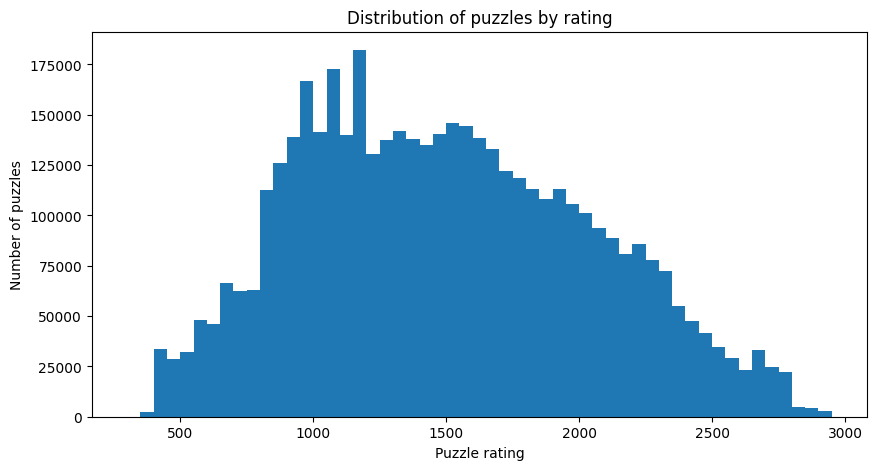

In [4]:
plt.figure(figsize=(10,5))

plt.hist(df["Rating"], bins=np.arange(300,3000,50))

plt.xlabel("Puzzle rating")
plt.ylabel("Number of puzzles")
plt.title("Distribution of puzzles by rating")

plt.show()

# 0. Рассмотрение данных + попытки в статистическое решение
---
Идея этого блока состоит в том, что рейтинг по ELO-системе при достаточном числе итераций будет гарантировать вероятность 0.5 решение игроком задачи своего рейтинга.
В таком случае статистическая информация для задач должна быть достаточной для предсказания рейтинга.

Так как тогда все эти вероятности решения - дискретизация логистической кривой

$$P(r) = \frac{1}{1+\exp{(-k(r-d))}}$$

In [5]:
import numpy as np
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

"""
P.S. У этой функции смешной интерфейс, чтобы потом сделать мини-трейн для обучаемого объединения 
результатов для статистики блиц и рапид вместо простого усреднения

"""


class SigmoidPuzzleRegressor:
    def __init__(self):
        self.rating_levels = np.array(
            [1050, 1150, 1250, 1350, 1450, 1550, 1650, 1750, 1850, 1950, 2050],
            dtype=float
        )

    @staticmethod
    def sigmoid(x, r0, k):
        return 1.0 / (1.0 + np.exp(-k * (x - r0)))

    def fit_sigmoid_from_probs(self, probs):
        x = self.rating_levels
        y = np.asarray(probs, dtype=float)

        y = np.clip(y, 1e-6, 1 - 1e-6)

        if y.min() <= 0.5 <= y.max():
            r0_init = np.interp(0.5, y, x)
        else:
            r0_init = x.mean()

        k_init = 0.01

        try:
            popt, _ = curve_fit(
                self.sigmoid,
                x,
                y,
                p0=[r0_init, k_init],
                bounds=([800.0, 1e-5], [3000.0, 1.0]),
                maxfev=10000
            )
            r0, k = popt
            y_fit = self.sigmoid(x, r0, k)
            mse = np.mean((y - y_fit) ** 2)
            return float(r0), float(k), float(mse)
        except Exception:
            return np.nan, np.nan, np.inf

    def predict_one(self, probs):
        probs = np.asarray(probs, dtype=float)

        rapid_probs = probs[:11]
        blitz_probs = probs[11:]

        rapid_r0, rapid_k, rapid_mse = self.fit_sigmoid_from_probs(rapid_probs)
        blitz_r0, blitz_k, blitz_mse = self.fit_sigmoid_from_probs(blitz_probs)

        if np.isfinite(rapid_r0) and np.isfinite(blitz_r0):
            w_rapid = 1.0 / (rapid_mse + 1e-8)
            w_blitz = 1.0 / (blitz_mse + 1e-8)
            rating_pred = (w_rapid * rapid_r0 + w_blitz * blitz_r0) / (w_rapid + w_blitz)
        elif np.isfinite(rapid_r0):
            rating_pred = rapid_r0
        elif np.isfinite(blitz_r0):
            rating_pred = blitz_r0
        else:
            rating_pred = np.nan

        return float(rating_pred)

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        X = np.asarray(X)
        preds = [self.predict_one(row) for row in X]
        return np.array(preds, dtype=float)

In [6]:
def show_sigmoid(row):

    ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

    rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050'
    ]

    probs = row[rapid_cols].values

    def sigmoid(x, r0, k):
        return 1/(1+np.exp(-k*(x-r0)))

    y = np.clip(probs, 1e-6, 1-1e-6)

    r0_init = np.interp(0.5, y, ratings) if (y.min()<=0.5<=y.max()) else ratings.mean()

    plt.figure(figsize=(7,4))

    plt.scatter(ratings,probs,label="data",s=60)

    try:
        params, _ = curve_fit(
            sigmoid,
            ratings,
            y,
            p0=[r0_init,0.01],
            maxfev=5000
        )

        r0,k = params

        x_dense = np.linspace(1000,2100,400)
        y_fit = sigmoid(x_dense,r0,k)


        plt.plot(x_dense,y_fit,label="sigmoid fit")
    except:
        pass

    plt.xlabel("Player rating")
    plt.ylabel("Success probability")
    plt.title(f"Task rating: {row['Rating']}")

    plt.legend()
    plt.grid(True)

    plt.show()

83


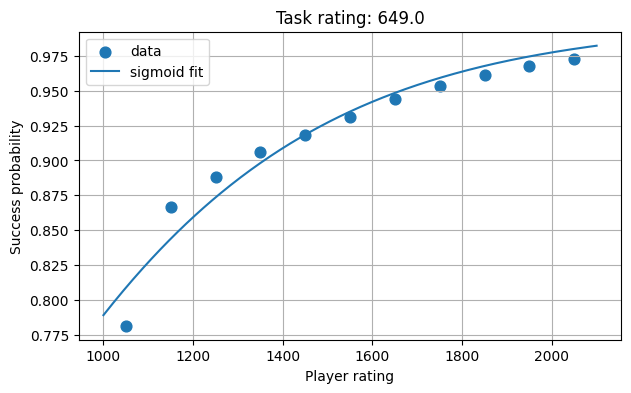

61


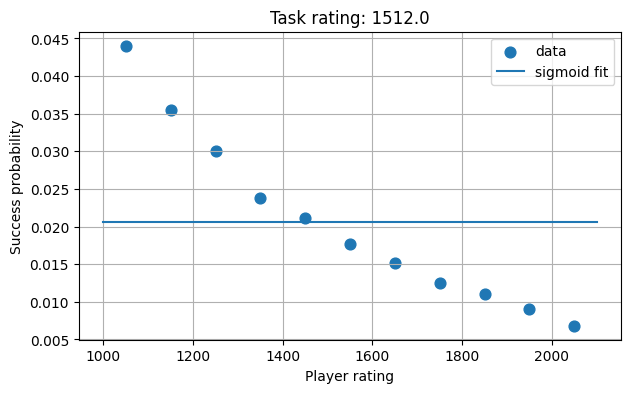

71


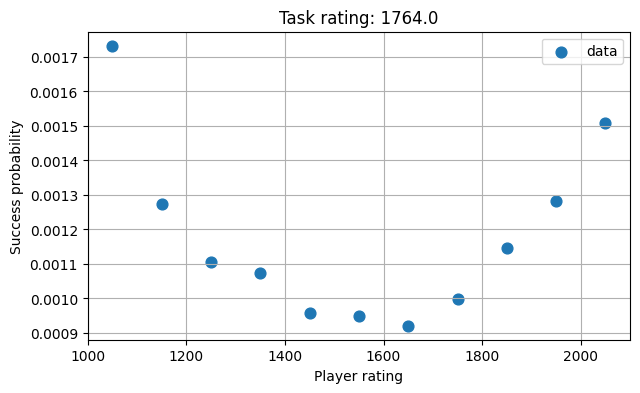

52


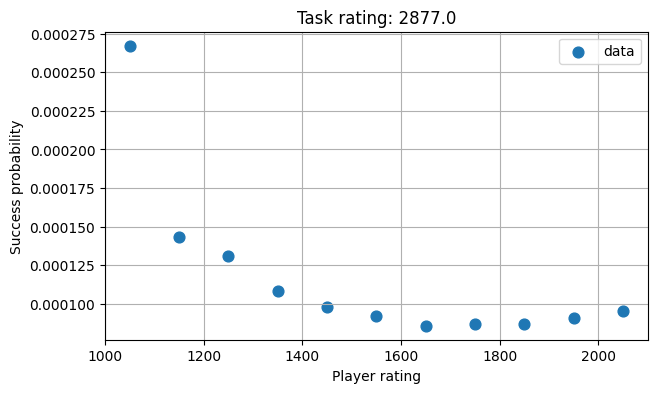

In [7]:
from random import randint
ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

rapid_cols = [
    'success_prob_rapid_1050','success_prob_rapid_1150','success_prob_rapid_1250',
    'success_prob_rapid_1350','success_prob_rapid_1450','success_prob_rapid_1550',
    'success_prob_rapid_1650','success_prob_rapid_1750','success_prob_rapid_1850',
    'success_prob_rapid_1950','success_prob_rapid_2050','Rating'
    ]
dfcut = df[rapid_cols]
for i in [38, 1, 83, 4]:
    x = randint(0, 100)
    row = dfcut.iloc[i]
    print(x)
    show_sigmoid(row)


In [8]:
feature_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150',
    'success_prob_rapid_1250', 'success_prob_rapid_1350',
    'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750',
    'success_prob_rapid_1850', 'success_prob_rapid_1950',
    'success_prob_rapid_2050',
    'success_prob_blitz_1050', 'success_prob_blitz_1150',
    'success_prob_blitz_1250', 'success_prob_blitz_1350',
    'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750',
    'success_prob_blitz_1850', 'success_prob_blitz_1950',
    'success_prob_blitz_2050'
]

df_small = df.sample(n=100_000, random_state=42)

X = df_small[feature_cols]
y = df_small['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = SigmoidPuzzleRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mask = ~np.isnan(y_pred)
y_test_valid = y_test.iloc[mask]
y_pred_valid = y_pred[mask]

print("R2:", r2_score(y_test_valid, y_pred_valid))
print("MAE:", mean_absolute_error(y_test_valid, y_pred_valid))
print("RMSE:", np.sqrt(mean_squared_error(y_test_valid, y_pred_valid)))

R2: -2.192841756411636
MAE: 787.5731687482042
RMSE: 971.8405724861537


# 1. Выделение ключевых признаков с помощью __Lasso__ и введение __Baseline__
---


In [10]:
dfreg = df[['Rating',
       'success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]
print("full size", dfreg.shape)
dfreg.dropna()
print("size without nans", dfreg.shape)


full size (4556924, 23)
size without nans (4556924, 23)


Посмотрим, насколько хорошо видна корреляция между предсказанными движком вероятностями 

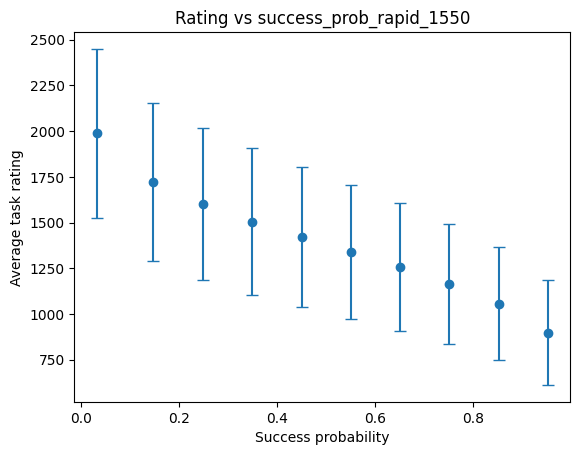

In [11]:
prob_col = 'success_prob_rapid_1550'
n_bins = 10
dfreg['prob_bin'] = pd.cut(dfreg[prob_col], bins=n_bins)

stats = dfreg.groupby('prob_bin').agg(
    prob_mean=(prob_col, 'mean'),
    rating_mean=('Rating', 'mean'),
    rating_std=('Rating', 'std'),
    count=('Rating', 'size')
).reset_index()

plt.errorbar(
    stats['prob_mean'],
    stats['rating_mean'],
    yerr=stats['rating_std'],
    fmt='o',
    capsize=4
)

plt.xlabel("Success probability")
plt.ylabel("Average task rating")
plt.title(f"Rating vs {prob_col}")

plt.show()

Перейдём к модели

In [12]:
X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=42, max_iter=100000)
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['lassocv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.38097969324555153
R2: 0.4922661083317229
MAE: 309.6591122505244
RMSE: 387.46381809534154


In [14]:
coef = model.named_steps['lassocv'].coef_

coef = model.named_steps['lassocv'].coef_
for feature, weight in zip(X.columns, coef):
    print(feature, weight)

success_prob_rapid_1050 0.0
success_prob_rapid_1150 -227.30510886700725
success_prob_rapid_1250 -0.0
success_prob_rapid_1350 -0.0
success_prob_rapid_1450 -44.69768929689032
success_prob_rapid_1550 -0.0
success_prob_rapid_1650 0.0
success_prob_rapid_1750 -0.0
success_prob_rapid_1850 0.0
success_prob_rapid_1950 -0.0
success_prob_rapid_2050 -30.991495718252605
success_prob_blitz_1050 -143.3870766019568
success_prob_blitz_1150 -0.0
success_prob_blitz_1250 0.0
success_prob_blitz_1350 0.0
success_prob_blitz_1450 0.0
success_prob_blitz_1550 136.6902281167511
success_prob_blitz_1650 -0.0
success_prob_blitz_1750 0.0
success_prob_blitz_1850 0.0
success_prob_blitz_1950 0.0
success_prob_blitz_2050 -80.07987559524263


In [15]:
coef_series = pd.Series(coef, index=X.columns)

nonzero = coef_series[coef_series != 0]
selected_features = nonzero.index.tolist()
print(selected_features)

['success_prob_rapid_1150', 'success_prob_rapid_1450', 'success_prob_rapid_2050', 'success_prob_blitz_1050', 'success_prob_blitz_1550', 'success_prob_blitz_2050']


Для лучшего линейного результата воспользуемся __Ridge__

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[['success_prob_rapid_1050', 'success_prob_rapid_1150',
       'success_prob_rapid_1250', 'success_prob_rapid_1350',
       'success_prob_rapid_1450', 'success_prob_rapid_1550',
       'success_prob_rapid_1650', 'success_prob_rapid_1750',
       'success_prob_rapid_1850', 'success_prob_rapid_1950',
       'success_prob_rapid_2050', 'success_prob_blitz_1050',
       'success_prob_blitz_1150', 'success_prob_blitz_1250',
       'success_prob_blitz_1350', 'success_prob_blitz_1450',
       'success_prob_blitz_1550', 'success_prob_blitz_1650',
       'success_prob_blitz_1750', 'success_prob_blitz_1850',
       'success_prob_blitz_1950', 'success_prob_blitz_2050']]

y = df['Rating']

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 50))
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Best alpha:", model.named_steps['ridgecv'].alpha_)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best alpha: 0.0517947467923121
R2: 0.5078148444321238
MAE: 303.9919553459086
RMSE: 381.4848824514513


О да, __Ridge__ лучше целых на 6 RMSE. Будем использовать этот результат как Baseline

# 2. Forest
---

1. Так как я умру от старости, пока лес переварит все данные, буду учить на подвыборке
2. Нужно придумать новые признаки, начнём с очевидных:
      1. Средняя вероятность - обычно очень хорошо для деревьев 
      2. Разница между блиц и рапид должна показать, насколько задача нетиповая и требовательна к глубине размышлений (т.к. игроки в блиц обычно сильно ограничены во времени, поэтому они более чуствительны к длинне задачи)
      3. Градиент по уровню игры
      4. Число ходов из решения
      5. Число фигур на поле


In [17]:
def count_pieces(fen):
    board_part = fen.split()[0]
    return sum(1 for ch in board_part if ch.isalpha())

def solution_length(moves):
    return len(moves.split())

In [18]:
dfcut = df.sample(n=500_000)

rapid_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150', 'success_prob_rapid_1250',
    'success_prob_rapid_1350', 'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750', 'success_prob_rapid_1850',
    'success_prob_rapid_1950', 'success_prob_rapid_2050'
]

blitz_cols = [
    'success_prob_blitz_1050', 'success_prob_blitz_1150', 'success_prob_blitz_1250',
    'success_prob_blitz_1350', 'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750', 'success_prob_blitz_1850',
    'success_prob_blitz_1950', 'success_prob_blitz_2050'
]

all_prob_cols = rapid_cols + blitz_cols

# AVG
dfcut['mean_prob_all'] = dfcut[all_prob_cols].mean(axis=1)
dfcut['mean_prob_rapid'] = dfcut[rapid_cols].mean(axis=1)
dfcut['mean_prob_blitz'] = dfcut[blitz_cols].mean(axis=1)

# Diff players
dfcut['gap_prob_mean'] = dfcut['mean_prob_rapid'] - dfcut['mean_prob_blitz']

# Grad
dfcut['grad_rapid'] = dfcut['success_prob_rapid_2050'] - dfcut['success_prob_rapid_1050']
dfcut['grad_blitz'] = dfcut['success_prob_blitz_2050'] - dfcut['success_prob_blitz_1050']

# board info
dfcut["piece_count"] = dfcut["FEN"].apply(count_pieces)
dfcut["solution_length"] = dfcut["Moves"].apply(solution_length)


In [19]:
selected_features = [
    'success_prob_rapid_1150', 'success_prob_rapid_1450', 'success_prob_rapid_2050', 
    'success_prob_blitz_1050', 'success_prob_blitz_1550', 'success_prob_blitz_2050',
    'mean_prob_all', 'mean_prob_rapid', 'mean_prob_blitz',
    'gap_prob_mean',
    'grad_rapid', 'grad_blitz',
    "piece_count", "solution_length"
                      ]
print(f"Currently {len(selected_features)} are chosen")

X = dfcut[selected_features]

y = dfcut['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Currently 14 are chosen


In [20]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.5591739757010113
MAE: 287.6967526160255
RMSE: 361.6774296500843


In [21]:
results = X_test.copy()

results["true_rating"] = y_test.values
results["pred_rating"] = y_pred

results["error"] = results["pred_rating"] - results["true_rating"]
results["abs_error"] = results["error"].abs()

In [22]:
best = results.sort_values("abs_error").head(10)

best[["true_rating", "pred_rating", "abs_error"]]

,true_rating,pred_rating,abs_error
3157048,1192,1191.997591,0.002409
4327005,1263,1263.003201,0.003201
2639626,1997,1997.005474,0.005474
81612,1904,1904.015061,0.015061
399588,948,947.982037,0.017963
2787606,1676,1675.979505,0.020495
1383892,1363,1362.978373,0.021627
1061578,1837,1837.024191,0.024191
289318,2270,2270.027063,0.027063
2942019,1632,1631.972920,0.027080


In [23]:
worst = results.sort_values("abs_error", ascending=False).head(10)

worst[["true_rating", "pred_rating", "abs_error"]]

,true_rating,pred_rating,abs_error
2485564,718,2300.917476,1582.917476
3731178,2523,996.491981,1526.508019
4042778,2745,1310.460774,1434.539226
3514307,2655,1244.618811,1410.381189
1365978,779,2187.159926,1408.159926
1003593,497,1898.938180,1401.938180
413967,599,1990.666394,1391.666394
2483222,485,1859.123685,1374.123685
38096,400,1770.089144,1370.089144
1193881,2585,1216.745129,1368.254871


In [25]:
X_test.loc[2485564]

success_prob_rapid_1150     0.000968
success_prob_rapid_1450     0.000527
success_prob_rapid_2050     0.000085
success_prob_blitz_1050     0.001674
success_prob_blitz_1550     0.000699
success_prob_blitz_2050     0.000125
mean_prob_all               0.000634
mean_prob_rapid             0.000508
mean_prob_blitz             0.000760
gap_prob_mean              -0.000252
grad_rapid                 -0.001191
grad_blitz                 -0.001549
piece_count                18.000000
solution_length             8.000000
Name: 2485564, dtype: float64

Выше посмотрели на худшие результаты предсказания модели, как видим, эти данные по большей части представляют собой неадекватные выбросы, так как задача с долей решаемости 0.03 не может иметь рейтинг 600, это даже тяжело списать на недостаточную сходимость рейтинга, ведь он стартует с 1500. 

Есть ощущение, что такие проблемы в данных созданы для того, чтобы в хакатоне победил тот, кто реализует анализ позиции.

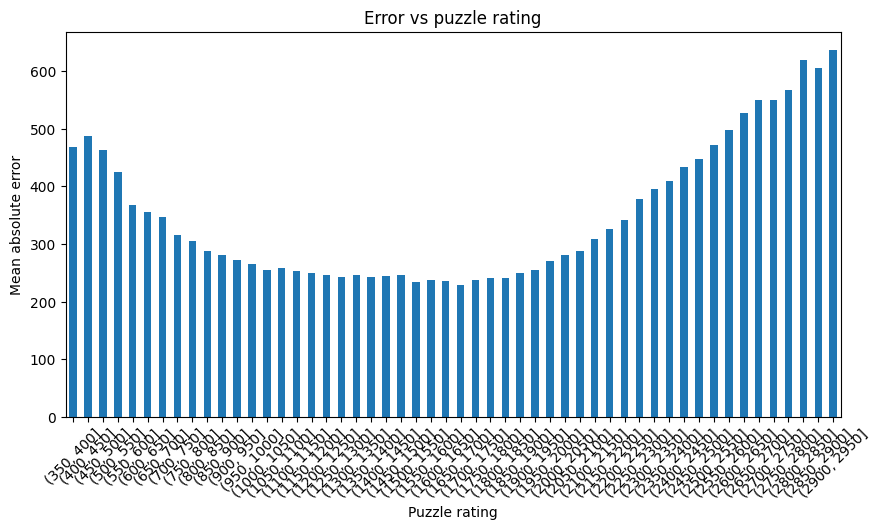

In [26]:
results = pd.DataFrame({
    "true_rating": y_test,
    "pred_rating": y_pred
})

results["abs_error"] = np.abs(results["pred_rating"] - results["true_rating"])
bins = np.arange(300, 3000, 50)

results["rating_bin"] = pd.cut(results["true_rating"], bins)
error_by_rating = results.groupby("rating_bin")["abs_error"].mean()


plt.figure(figsize=(10,5))

error_by_rating.plot(kind="bar")

plt.ylabel("Mean absolute error")
plt.xlabel("Puzzle rating")
plt.title("Error vs puzzle rating")

plt.xticks(rotation=45)

plt.show()

Как видим, модель страдает на тяжёлых задачах, это предсказуемо т.к.
1. в основном задачи сосредоточены вблизи среднего рейтинга
2. на сложных задачах маленькие вероятности успеха, шум на них даёт большой вклад
3. сложность тяжёлых задач часто заключается в сложной идее, которая не связана с числом ходов / фигур и тд 

# 3. Boost
---

In [29]:
import chess
ratings = np.array([1050,1150,1250,1350,1450,1550,1650,1750,1850,1950,2050])

def grad(values):
    a, b = np.polyfit(ratings, values, 1)
    return a

def count_pieces(fen):
    board_part = fen.split()[0]
    return sum(1 for ch in board_part if ch.isalpha())

def solution_length(moves):
    return len(moves.split())

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0,
}

def material_of_side(board, color):
    total = 0
    for piece_type, value in PIECE_VALUES.items():
        total += len(board.pieces(piece_type, color)) * value
    return total


def extract_result_features(fen, moves_str):
    board = chess.Board(fen)
    solver_color = board.turn
    opp_color = not solver_color

    # Материал до решения
    solver_material_before = material_of_side(board, solver_color)
    opp_material_before = material_of_side(board, opp_color)
    balance_before = solver_material_before - opp_material_before

    has_capture = 0
    num_captures = 0
    has_check = 0
    num_checks = 0
    has_promotion = 0
    num_promotions = 0
    has_castling_move = 0
    num_castling_moves = 0

    moves = moves_str.split() if isinstance(moves_str, str) and moves_str.strip() else []

    for move_uci in moves:
        try:
            move = chess.Move.from_uci(move_uci)
        except ValueError:
            continue

        if move not in board.legal_moves:
            continue

        if board.is_capture(move):
            has_capture = 1
            num_captures += 1

        if board.is_castling(move):
            has_castling_move = 1
            num_castling_moves += 1

        if move.promotion is not None:
            has_promotion = 1
            num_promotions += 1

        board.push(move)

        if board.is_check():
            has_check = 1
            num_checks += 1

    # Материал после решения
    solver_material_after = material_of_side(board, solver_color)
    opp_material_after = material_of_side(board, opp_color)
    balance_after = solver_material_after - opp_material_after

    # Изменения материала
    solver_material_change = solver_material_after - solver_material_before
    opp_material_change = opp_material_after - opp_material_before
    balance_change = balance_after - balance_before

    # Итог позиции
    is_checkmate = int(board.is_checkmate())
    is_stalemate = int(board.is_stalemate())
    is_insufficient_material = int(board.is_insufficient_material())
    is_repetition_claimable = int(board.can_claim_threefold_repetition())
    is_fifty_moves_claimable = int(board.can_claim_fifty_moves())

    # Эвристический "тип результата"
    wins_material = int(balance_change > 0)
    loses_material = int(balance_change < 0)
    equal_material = int(balance_change == 0)

    return pd.Series({
        "solver_material_before": solver_material_before,
        "opp_material_before": opp_material_before,
        "balance_before": balance_before,

        "solver_material_after": solver_material_after,
        "opp_material_after": opp_material_after,
        "balance_after": balance_after,

        "solver_material_change": solver_material_change,
        "opp_material_change": opp_material_change,
        "balance_change": balance_change,

        "wins_material": wins_material,
        "loses_material": loses_material,
        "equal_material": equal_material,

        "is_checkmate": is_checkmate,
        "is_stalemate": is_stalemate,
        "is_insufficient_material": is_insufficient_material,
        "is_repetition_claimable": is_repetition_claimable,
        "is_fifty_moves_claimable": is_fifty_moves_claimable,

        "has_capture": has_capture,
        "num_captures": num_captures,
        "has_check": has_check,
        "num_checks": num_checks,
        "has_promotion": has_promotion,
        "num_promotions": num_promotions,
        "has_castling_move": has_castling_move,
        "num_castling_moves": num_castling_moves,
    })

def extract_fen_features(fen):
    board = chess.Board(fen)

    white_material = material_of_side(board, chess.WHITE)
    black_material = material_of_side(board, chess.BLACK)

    return pd.Series({
        "white_material": white_material,
        "black_material": black_material,
        "material_balance": white_material - black_material,
        "white_castle_kingside": int(board.has_kingside_castling_rights(chess.WHITE)),
        "white_castle_queenside": int(board.has_queenside_castling_rights(chess.WHITE)),
        "black_castle_kingside": int(board.has_kingside_castling_rights(chess.BLACK)),
        "black_castle_queenside": int(board.has_queenside_castling_rights(chess.BLACK)),
        "any_castling_rights": int(
            board.has_kingside_castling_rights(chess.WHITE)
            or board.has_queenside_castling_rights(chess.WHITE)
            or board.has_kingside_castling_rights(chess.BLACK)
            or board.has_queenside_castling_rights(chess.BLACK)
        ),
        "legal_moves_count": board.legal_moves.count(),
    })

def extract_move_features(fen, moves_str):
    board = chess.Board(fen)

    has_capture = 0
    num_captures = 0
    has_check = 0
    num_checks = 0

    moves = moves_str.split() if isinstance(moves_str, str) and moves_str.strip() else []

    for move_uci in moves:
        try:
            move = chess.Move.from_uci(move_uci)
        except ValueError:
            continue

        if move not in board.legal_moves:
            continue

        if board.is_capture(move):
            has_capture = 1
            num_captures += 1

        board.push(move)

        if board.is_check():
            has_check = 1
            num_checks += 1

    return pd.Series({
        "has_capture": has_capture,
        "num_captures": num_captures,
        "has_check": has_check,
        "num_checks": num_checks,
    })

Ещё накидаем от души немножко признаков

In [30]:
dfcut = df.sample(n=100_000) # анализ 4.5 млн партий дело не быстрое...

rapid_cols = [
    'success_prob_rapid_1050', 'success_prob_rapid_1150', 'success_prob_rapid_1250',
    'success_prob_rapid_1350', 'success_prob_rapid_1450', 'success_prob_rapid_1550',
    'success_prob_rapid_1650', 'success_prob_rapid_1750', 'success_prob_rapid_1850',
    'success_prob_rapid_1950', 'success_prob_rapid_2050'
]

blitz_cols = [
    'success_prob_blitz_1050', 'success_prob_blitz_1150', 'success_prob_blitz_1250',
    'success_prob_blitz_1350', 'success_prob_blitz_1450', 'success_prob_blitz_1550',
    'success_prob_blitz_1650', 'success_prob_blitz_1750', 'success_prob_blitz_1850',
    'success_prob_blitz_1950', 'success_prob_blitz_2050'
]

all_prob_cols = rapid_cols + blitz_cols
print("already done: ", end="")

# AVG
dfcut['mean_prob_rapid'] = dfcut[rapid_cols].mean(axis=1)
dfcut['mean_prob_blitz'] = dfcut[blitz_cols].mean(axis=1)
print("avg ", end="")

# std
dfcut["std_prob_rapid"] = dfcut[rapid_cols].std(axis=1)
dfcut["std_prob_blitz"] = dfcut[blitz_cols].std(axis=1)
dfcut["range_prob_rapid"] = dfcut[rapid_cols].max(axis=1) - dfcut[rapid_cols].min(axis=1)
dfcut["range_prob_blitz"] = dfcut[blitz_cols].max(axis=1) - dfcut[blitz_cols].min(axis=1)
print("std ", end="")

# Diff players
dfcut['gap_prob_mean'] = dfcut['mean_prob_rapid'] - dfcut['mean_prob_blitz']
print("players ", end="")

# Grad
dfcut["grad_rapid"] = dfcut["success_prob_rapid_2050"] - dfcut["success_prob_rapid_1050"]
dfcut["grad_blitz"] = dfcut["success_prob_blitz_2050"] - dfcut["success_prob_blitz_1050"]
print("grad ", end="")

# Min - max
dfcut["min_prob_rapid"] = dfcut[rapid_cols].min(axis=1)
dfcut["min_prob_blitz"] = dfcut[blitz_cols].min(axis=1)
dfcut["max_prob_rapid"] = dfcut[rapid_cols].max(axis=1)
dfcut["max_prob_blitz"] = dfcut[blitz_cols].max(axis=1)
print("min-max ", end="")

# board info
dfcut["piece_count"] = dfcut["FEN"].apply(count_pieces)
dfcut["solution_length"] = dfcut["Moves"].apply(solution_length)
dfcut[[
    "white_material",
    "black_material",
    "material_balance",
    "white_castle_kingside",
    "white_castle_queenside",
    "black_castle_kingside",
    "black_castle_queenside",
    "any_castling_rights",
    "legal_moves_count"
]] = dfcut["FEN"].apply(extract_fen_features)
dfcut[[
    "solver_material_before",
    "opp_material_before",
    "balance_before",
    "solver_material_after",
    "opp_material_after",
    "balance_after",
    "solver_material_change",
    "opp_material_change",
    "balance_change",
    "wins_material",
    "loses_material",
    "equal_material",
    "is_checkmate",
    "is_stalemate",
    "is_insufficient_material",
    "is_repetition_claimable",
    "is_fifty_moves_claimable",
    "has_capture",
    "num_captures",
    "has_check",
    "num_checks",
    "has_promotion",
    "num_promotions",
    "has_castling_move",
    "num_castling_moves"
]] = dfcut.apply(
    lambda row: extract_result_features(row["FEN"], row["Moves"]),
    axis=1
)

print("board ", end="")

already done: avg std players grad min-max board 

In [31]:
selected_features = [
    # stock
    'success_prob_rapid_1150',
    'success_prob_rapid_1450',
    'success_prob_rapid_2050',
    'success_prob_blitz_1050',
    'success_prob_blitz_1550',
    'success_prob_blitz_2050',

    # prob stats
    "mean_prob_rapid",
    "mean_prob_blitz",
    "std_prob_rapid",
    "std_prob_blitz",
    "range_prob_rapid",
    "range_prob_blitz",
    "min_prob_rapid",
    "min_prob_blitz",
    "max_prob_rapid",
    "max_prob_blitz",

    # rapid/blitz diff
    "gap_prob_mean",

    # grads
    "grad_rapid",
    "grad_blitz",

    # board info
    "piece_count",
    "solution_length",

    "white_material",
    "black_material",
    "material_balance",

    "white_castle_kingside",
    "white_castle_queenside",
    "black_castle_kingside",
    "black_castle_queenside",
    "any_castling_rights",

    "legal_moves_count",

    # solution
    "balance_before",
    "balance_after",
    "balance_change",
    "wins_material",
    "loses_material",
    "equal_material",
    "is_checkmate",
    "is_stalemate",
    "has_capture",
    "num_captures",
    "has_check",
    "num_checks",
    "has_promotion",
    "num_promotions",
]
print(f"Currently {len(selected_features)} are chosen")

X = dfcut[selected_features]

y = dfcut['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Currently 44 are chosen


In [33]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    tree_method="hist",
    device="cuda",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.6766258478164673
MAE: 244.81329345703125
RMSE: 309.2663571866491


<Axes: >

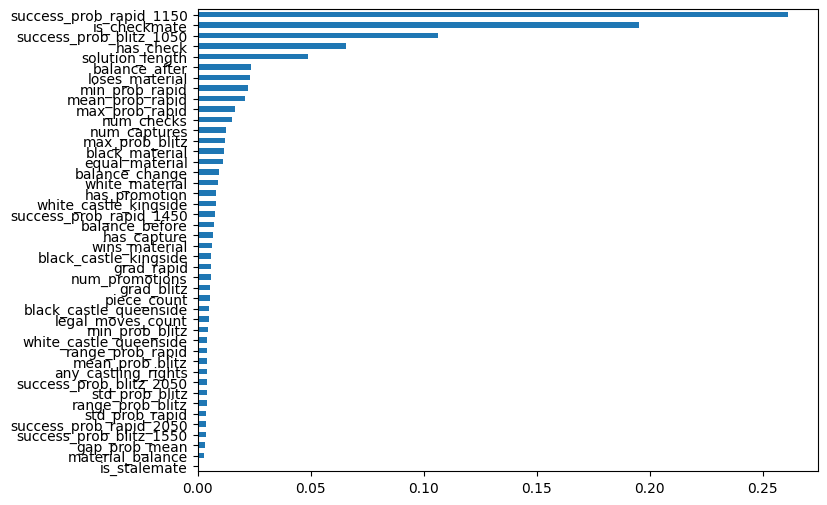

In [ ]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values().plot.barh(figsize=(8,6))

In [ ]:
results = X_test.copy()

results["true_rating"] = y_test.values
results["pred_rating"] = y_pred

results["error"] = results["pred_rating"] - results["true_rating"]
results["abs_error"] = results["error"].abs()

In [ ]:
worst = results.sort_values("abs_error", ascending=False).head(10)

worst[["true_rating", "pred_rating", "abs_error"]]

,true_rating,pred_rating,abs_error
340190,2665,1341.883789,1323.116211
1066994,600,1885.682739,1285.682739
2901214,1333,2597.751709,1264.751709
429352,2981,1777.930908,1203.069092
2143917,2508,1305.735962,1202.264038
1037067,1246,2424.166992,1178.166992
1660975,2431,1258.632446,1172.367554
3007363,2442,1271.846313,1170.153687
2320522,2522,1352.798462,1169.201538
819731,2251,1086.166260,1164.833740


Rating: 600
Moves: d4c6 b4b3 c2b3 c3c2 c6b4 c2c1q


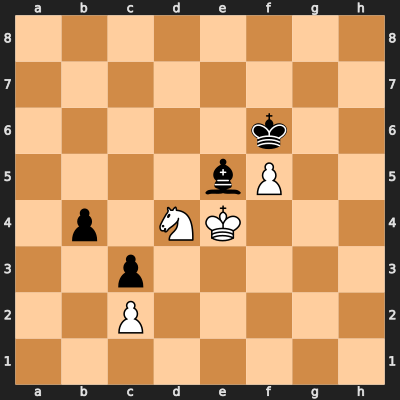

In [ ]:
import chess.svg
from IPython.display import SVG

def show_puzzle(row, size=400):
    idx = row.name

    fen = dfcut.loc[idx, "FEN"]
    moves = dfcut.loc[idx, "Moves"]
    rating = dfcut.loc[idx, "Rating"]

    board = chess.Board(fen)

    print("Rating:", rating)
    print("Moves:", moves)

    return SVG(chess.svg.board(board, size=size))

show_puzzle(X_test.loc[1066994])

# 4. CNN с начальной позицией + ручной инфой о решении
---

Как было получено в прошлом разделе, вероятностные признаки имеют большие проблемы, будем пробовать оценивать саму позицию напрямую.

In [7]:
dfnn = df[["FEN", "Moves", "Rating"]]
dfnn.head(5)

,FEN,Moves,Rating
0,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1902
1,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1512
2,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1300
3,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1078
4,r4r2/1p3pkp/p5p1/3R1N1Q/3P4/8/P1q2P2/3R2K1 b -...,g6f5 d5c5 c2e4 h5g5 g7h8 g5f6,2877


Для передачи позиции в сеть будем пользоваться 8x8x12 сигналом:

- `0` — white pawn  
- `1` — white knight  
- `2` — white bishop  
- `3` — white rook  
- `4` — white queen  
- `5` — white king  
- `6` — black pawn  
- `7` — black knight  
- `8` — black bishop  
- `9` — black rook  
- `10` — black queen  
- `11` — black king

In [3]:
piece_map = {
    'P':0,'N':1,'B':2,'R':3,'Q':4,'K':5,
    'p':6,'n':7,'b':8,'r':9,'q':10,'k':11
}

import numpy as np

piece_map = {
    'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
    'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11
}

def square_to_coords(square):
    """
    Переводит шахматное поле, например 'e3', в координаты массива [r, c].
    r = 0 соответствует 8-й горизонтали
    c = 0 соответствует файлу a
    """
    file_char = square[0]   # 'a'..'h'
    rank_char = square[1]   # '1'..'8'

    c = ord(file_char) - ord('a')
    r = 8 - int(rank_char)

    return r, c


def fen_to_tensor(fen):
    """
    Преобразует FEN в тензор формы (18, 8, 8)

    Каналы:
    0-5   : белые
    6-11  : чёрные
    12    : чей ход (1 = white, 0 = black)
    13    : белые могут рокировать в короткую сторону (K)
    14    : белые могут рокировать в длинную сторону (Q)
    15    : чёрные могут рокировать в короткую сторону (k)
    16    : чёрные могут рокировать в длинную сторону (q)
    17    : взятие на проходе (единица только в одной клетке, если оно есть)
    """
    tensor = np.zeros((18, 8, 8), dtype=np.float32)

    parts = fen.split()
    board_part = parts[0]
    turn_part = parts[1]
    castling_part = parts[2]
    en_passant_part = parts[3]

    # --- 1. Расстановка фигур ---
    rows = board_part.split('/')
    for r, row in enumerate(rows):
        c = 0
        for ch in row:
            if ch.isdigit():
                c += int(ch)
            else:
                tensor[piece_map[ch], r, c] = 1.0
                c += 1

    # --- 2. Чей ход ---
    if turn_part == 'w':
        tensor[12, :, :] = 1.0
    else:
        tensor[12, :, :] = 0.0

    # --- 3. Права на рокировку ---
    if 'K' in castling_part:
        tensor[13, :, :] = 1.0
    if 'Q' in castling_part:
        tensor[14, :, :] = 1.0
    if 'k' in castling_part:
        tensor[15, :, :] = 1.0
    if 'q' in castling_part:
        tensor[16, :, :] = 1.0

    # --- 4. Поле en passant ---
    if en_passant_part != '-':
        r_ep, c_ep = square_to_coords(en_passant_part)
        tensor[17, r_ep, c_ep] = 1.0

    return tensor

def moves_to_features(moves: str) -> np.ndarray:
    moves_list = moves.split() if isinstance(moves, str) and moves.strip() else []

    solution_length = len(moves_list)
    num_promotions = sum('=' in m or len(m) == 5 for m in moves_list)
    has_promotion = 1.0 if num_promotions > 0 else 0.0

    num_checks = sum('+' in m for m in moves_list)
    num_mates = sum('#' in m for m in moves_list)
    num_captures = sum('x' in m for m in moves_list)

    num_king_moves = sum(m.startswith('K') for m in moves_list)
    num_queen_moves = sum(m.startswith('Q') for m in moves_list)
    num_rook_moves = sum(m.startswith('R') for m in moves_list)
    num_bishop_moves = sum(m.startswith('B') for m in moves_list)
    num_knight_moves = sum(m.startswith('N') for m in moves_list)

    num_castles = sum(m in ['O-O', 'O-O-O'] for m in moves_list)

    return np.array([
        solution_length,
        num_promotions,
        has_promotion,
        num_checks,
        num_mates,
        num_captures,
        num_king_moves,
        num_queen_moves,
        num_rook_moves,
        num_bishop_moves,
        num_knight_moves,
        num_castles,
    ], dtype=np.float32)

In [4]:
from torch.utils.data import Dataset
import torch
import numpy as np

class ChessPuzzleDataset(Dataset):
    def __init__(self, df, target_col="Rating_norm", precompute=True):
        self.targets = df[target_col].values.astype(np.float32)

        if precompute:
            self.boards = np.stack([fen_to_tensor(fen) for fen in df["FEN"].values]).astype(np.float32)
            self.move_feats = np.stack([moves_to_features(m) for m in df["Moves"].values]).astype(np.float32)
        else:
            self.fens = df["FEN"].values
            self.moves = df["Moves"].values
            self.boards = None
            self.move_feats = None

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        if self.boards is not None:
            board = self.boards[idx]
            move_feats = self.move_feats[idx]
        else:
            board = fen_to_tensor(self.fens[idx]).astype(np.float32)
            move_feats = moves_to_features(self.moves[idx]).astype(np.float32)

        return (
            torch.from_numpy(board),
            torch.from_numpy(move_feats),
            torch.tensor(self.targets[idx], dtype=torch.float32),
        )

In [13]:
from sklearn.model_selection import train_test_split


df_small = df.sample(n=1000_000, random_state=42).copy()

train_df, val_df = train_test_split(
    df_small,
    test_size=0.2,
    random_state=42
)

y_mean = train_df["Rating"].mean()
y_std = train_df["Rating"].std()

train_df["Rating_norm"] = (train_df["Rating"] - y_mean) / y_std
val_df["Rating_norm"] = (val_df["Rating"] - y_mean) / y_std

from torch.utils.data import DataLoader

train_dataset = ChessPuzzleDataset(train_df, precompute=True)
val_dataset = ChessPuzzleDataset(val_df, precompute=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [6]:
import torch.nn as nn

class ChessCNNRegressor(nn.Module):
    def __init__(self, move_feat_dim):
        super().__init__()

        self.board_cnn = nn.Sequential(
            nn.Conv2d(18, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.move_mlp = nn.Sequential(
            nn.Linear(move_feat_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(64 + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, board, move_feats):
        # board: (B, 12, 8, 8)
        x_board = self.board_cnn(board)         # (B, 64, 1, 1)
        x_board = x_board.flatten(1)            # (B, 64)

        x_move = self.move_mlp(move_feats)      # (B, 16)

        x = torch.cat([x_board, x_move], dim=1) # (B, 80)
        out = self.head(x).squeeze(1)           # (B,)
        return out

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch
import numpy as np

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for board, move_feats, target in loader:
        board = board.to(device)
        move_feats = move_feats.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        pred = model(board, move_feats)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * board.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, y_mean, y_std):
    model.eval()
    total_loss = 0.0

    y_true = []
    y_pred = []

    for board, move_feats, target in loader:
        board = board.to(device)
        move_feats = move_feats.to(device)
        target = target.to(device)

        pred = model(board, move_feats)
        loss = criterion(pred, target)

        total_loss += loss.item() * board.size(0)

        y_true.append(target.cpu().numpy())
        y_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    y_true_real = y_true * y_std + y_mean
    y_pred_real = y_pred * y_std + y_mean

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "r2": r2_score(y_true_real, y_pred_real),
        "mae": mean_absolute_error(y_true_real, y_pred_real),
        "rmse": np.sqrt(mean_squared_error(y_true_real, y_pred_real)),
    }
    return metrics

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChessCNNRegressor(move_feat_dim=12).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

In [9]:
import torch
print(torch.__version__)
print(torch.cuda.device_count())
torch.cuda.is_available()

2.10.0+cu126
1


True

In [10]:
device

device(type='cuda')

In [14]:
best_val_loss = float("inf")
best_state = None
patience = 3
bad_epochs = 0

num_epochs = 20

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, y_mean, y_std)
    scheduler.step(val_metrics["loss"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"R2={val_metrics['r2']:.4f} | "
        f"MAE={val_metrics['mae']:.2f} | "
        f"RMSE={val_metrics['rmse']:.2f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=0.3071 | val_loss=0.2968 | R2=0.3521 | MAE=352.01 | RMSE=437.88
Epoch 02 | train_loss=0.2959 | val_loss=0.2921 | R2=0.3649 | MAE=348.98 | RMSE=433.53
Epoch 03 | train_loss=0.2923 | val_loss=0.2900 | R2=0.3707 | MAE=347.73 | RMSE=431.53
Epoch 04 | train_loss=0.2905 | val_loss=0.2886 | R2=0.3738 | MAE=346.73 | RMSE=430.47
Epoch 05 | train_loss=0.2890 | val_loss=0.2879 | R2=0.3752 | MAE=346.08 | RMSE=430.00
Epoch 06 | train_loss=0.2879 | val_loss=0.2872 | R2=0.3771 | MAE=345.69 | RMSE=429.34
Epoch 07 | train_loss=0.2868 | val_loss=0.2865 | R2=0.3792 | MAE=345.36 | RMSE=428.61
Epoch 08 | train_loss=0.2860 | val_loss=0.2861 | R2=0.3790 | MAE=344.68 | RMSE=428.67
Epoch 09 | train_loss=0.2853 | val_loss=0.2857 | R2=0.3805 | MAE=344.49 | RMSE=428.16
Epoch 10 | train_loss=0.2846 | val_loss=0.2855 | R2=0.3806 | MAE=344.26 | RMSE=428.13
Epoch 11 | train_loss=0.2840 | val_loss=0.2851 | R2=0.3824 | MAE=344.21 | RMSE=427.50
Epoch 12 | train_loss=0.2833 | val_loss=0.2848 | R2=0.

# 5. CNN + transformer
---

In [18]:
piece_map = {
    'P': 0, 'N': 1, 'B': 2, 'R': 3, 'Q': 4, 'K': 5,
    'p': 6, 'n': 7, 'b': 8, 'r': 9, 'q': 10, 'k': 11
}

def square_to_coords(square):
    file_char = square[0]
    rank_char = square[1]
    c = ord(file_char) - ord('a')
    r = 8 - int(rank_char)
    return r, c

def fen_to_tensor(fen):
    tensor = np.zeros((18, 8, 8), dtype=np.float32)

    parts = fen.split()
    board_part = parts[0]
    turn_part = parts[1]
    castling_part = parts[2]
    en_passant_part = parts[3]

    rows = board_part.split('/')
    for r, row in enumerate(rows):
        c = 0
        for ch in row:
            if ch.isdigit():
                c += int(ch)
            else:
                tensor[piece_map[ch], r, c] = 1.0
                c += 1

    if turn_part == 'w':
        tensor[12, :, :] = 1.0

    if 'K' in castling_part:
        tensor[13, :, :] = 1.0
    if 'Q' in castling_part:
        tensor[14, :, :] = 1.0
    if 'k' in castling_part:
        tensor[15, :, :] = 1.0
    if 'q' in castling_part:
        tensor[16, :, :] = 1.0

    if en_passant_part != '-':
        r_ep, c_ep = square_to_coords(en_passant_part)
        tensor[17, r_ep, c_ep] = 1.0

    return tensor

In [ ]:
import chess

def puzzle_to_sequence(fen, moves, max_len=12):

    board = chess.Board(fen)
    states = [fen_to_tensor(board.fen())]

    move_list = moves.split() if isinstance(moves, str) and moves.strip() else []

    for mv in move_list:
        if len(states) >= max_len:
            break
        try:
            board.push_uci(mv)
            states.append(fen_to_tensor(board.fen()))
        except Exception:
            break

    seq_len = len(states)

    if seq_len < max_len:
        pad = np.zeros((max_len - seq_len, 18, 8, 8), dtype=np.float32)
        states = np.concatenate([np.stack(states).astype(np.float32), pad], axis=0)
    else:
        states = np.stack(states[:max_len]).astype(np.float32)

    return states, seq_len

In [20]:
from torch.utils.data import Dataset

class ChessSequenceDataset(Dataset):
    def __init__(self, df, target_col="Rating_norm", max_len=12):
        self.fens = df["FEN"].values
        self.moves = df["Moves"].values
        self.targets = df[target_col].values.astype(np.float32)
        self.max_len = max_len

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        seq, seq_len = puzzle_to_sequence(
            self.fens[idx],
            self.moves[idx],
            max_len=self.max_len
        )

        return (
            torch.from_numpy(seq),                         # (T, 18, 8, 8)
            torch.tensor(seq_len, dtype=torch.long),      # реальная длина
            torch.tensor(self.targets[idx], dtype=torch.float32)
        )

In [21]:
import torch.nn as nn

class BoardCNNEncoder(nn.Module):
    def __init__(self, in_channels=18, emb_dim=128):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.proj = nn.Linear(128, emb_dim)

    def forward(self, x):
        # x: (B*T, 18, 8, 8)
        x = self.features(x)      # (B*T, 128, 1, 1)
        x = x.flatten(1)          # (B*T, 128)
        x = self.proj(x)          # (B*T, emb_dim)
        return x

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T]

In [ ]:
class ChessCNNTransformerRegressor(nn.Module):
    def __init__(
        self,
        in_channels=18,
        emb_dim=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=12
    ):
        super().__init__()

        self.board_encoder = BoardCNNEncoder(in_channels=in_channels, emb_dim=emb_dim)
        self.pos_encoder = PositionalEncoding(d_model=emb_dim, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, seq, seq_lens):
        """
        seq: (B, T, 18, 8, 8)
        seq_lens: (B,)
        """
        B, T, C, H, W = seq.shape

        x = seq.view(B * T, C, H, W)
        x = self.board_encoder(x)          # (B*T, emb_dim)
        x = x.view(B, T, -1)               # (B, T, emb_dim)

        x = self.pos_encoder(x)

        device = seq.device
        positions = torch.arange(T, device=device).unsqueeze(0)   # (1, T)
        pad_mask = positions >= seq_lens.unsqueeze(1)             # (B, T)

        x = self.transformer(x, src_key_padding_mask=pad_mask)    # (B, T, emb_dim)

        # masked mean pooling
        valid_mask = (~pad_mask).unsqueeze(-1).float()            # (B, T, 1)
        x_sum = (x * valid_mask).sum(dim=1)                       # (B, emb_dim)
        x_cnt = valid_mask.sum(dim=1).clamp(min=1.0)              # (B, 1)
        x_pool = x_sum / x_cnt

        out = self.head(x_pool).squeeze(1)                        # (B,)
        return out

In [29]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

df_small = df.sample(n=1_000_000, random_state=42).copy()

train_df, val_df = train_test_split(
    df_small,
    test_size=0.2,
    random_state=42
)

y_mean = train_df["Rating"].mean()
y_std = train_df["Rating"].std()

train_df["Rating_norm"] = (train_df["Rating"] - y_mean) / y_std
val_df["Rating_norm"] = (val_df["Rating"] - y_mean) / y_std

max_len = 12

train_dataset = ChessSequenceDataset(train_df, target_col="Rating_norm", max_len=max_len)
val_dataset = ChessSequenceDataset(val_df, target_col="Rating_norm", max_len=max_len)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for seq, seq_lens, target in loader:
        seq = seq.to(device, non_blocking=True)
        seq_lens = seq_lens.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(seq, seq_lens)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seq.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device, y_mean, y_std):
    model.eval()
    total_loss = 0.0

    y_true = []
    y_pred = []

    for seq, seq_lens, target in loader:
        seq = seq.to(device, non_blocking=True)
        seq_lens = seq_lens.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        pred = model(seq, seq_lens)
        loss = criterion(pred, target)

        total_loss += loss.item() * seq.size(0)

        y_true.append(target.cpu().numpy())
        y_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    y_true_real = y_true * y_std + y_mean
    y_pred_real = y_pred * y_std + y_mean

    return {
        "loss": total_loss / len(loader.dataset),
        "r2": r2_score(y_true_real, y_pred_real),
        "mae": mean_absolute_error(y_true_real, y_pred_real),
        "rmse": np.sqrt(mean_squared_error(y_true_real, y_pred_real)),
    }

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = ChessCNNTransformerRegressor(
    in_channels=18,
    emb_dim=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    max_len=max_len
).to(device)

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

cuda


C:\Users\Admin\AppData\Local\Temp\ipykernel_6020\3841346822.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [32]:
best_val_loss = float("inf")
best_state = None
patience = 4
bad_epochs = 0

num_epochs = 20

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device, y_mean, y_std)

    scheduler.step(val_metrics["loss"])

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"R2={val_metrics['r2']:.4f} | "
        f"MAE={val_metrics['mae']:.2f} | "
        f"RMSE={val_metrics['rmse']:.2f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=0.2450 | val_loss=0.2106 | R2=0.5569 | MAE=287.45 | RMSE=362.11
Epoch 02 | train_loss=0.2088 | val_loss=0.1969 | R2=0.5892 | MAE=277.92 | RMSE=348.66
Epoch 03 | train_loss=0.1963 | val_loss=0.1877 | R2=0.6069 | MAE=267.54 | RMSE=341.08
Epoch 04 | train_loss=0.1883 | val_loss=0.1834 | R2=0.6177 | MAE=266.72 | RMSE=336.36
Epoch 05 | train_loss=0.1822 | val_loss=0.1811 | R2=0.6237 | MAE=264.52 | RMSE=333.69
Epoch 06 | train_loss=0.1776 | val_loss=0.1785 | R2=0.6274 | MAE=259.77 | RMSE=332.03
Epoch 07 | train_loss=0.1734 | val_loss=0.1785 | R2=0.6297 | MAE=263.22 | RMSE=331.00
Epoch 08 | train_loss=0.1703 | val_loss=0.1764 | R2=0.6336 | MAE=259.91 | RMSE=329.28
Epoch 09 | train_loss=0.1672 | val_loss=0.1717 | R2=0.6435 | MAE=256.20 | RMSE=324.78
Epoch 10 | train_loss=0.1643 | val_loss=0.1715 | R2=0.6427 | MAE=254.38 | RMSE=325.15
Epoch 11 | train_loss=0.1623 | val_loss=0.1731 | R2=0.6382 | MAE=254.03 | RMSE=327.19
Epoch 12 | train_loss=0.1599 | val_loss=0.1698 | R2=0.

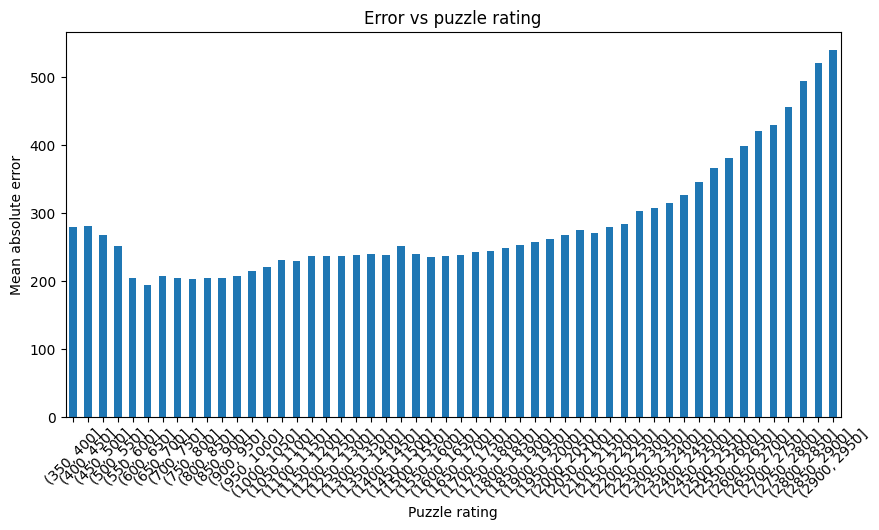

In [34]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for seq, seq_lens, target in val_loader:

        seq = seq.to(device)
        seq_lens = seq_lens.to(device)

        pred = model(seq, seq_lens)

        y_true.append(target.numpy())
        y_pred.append(pred.cpu().numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

y_true = y_true * y_std + y_mean
y_pred = y_pred * y_std + y_mean

results = pd.DataFrame({
    "true_rating": y_true,
    "pred_rating": y_pred
})

results["abs_error"] = np.abs(results["pred_rating"] - results["true_rating"])

bins = np.arange(300, 3000, 50)

results["rating_bin"] = pd.cut(results["true_rating"], bins)

error_by_rating = results.groupby("rating_bin")["abs_error"].mean()

plt.figure(figsize=(10,5))

error_by_rating.plot(kind="bar")

plt.ylabel("Mean absolute error")
plt.xlabel("Puzzle rating")
plt.title("Error vs puzzle rating")

plt.xticks(rotation=45)

plt.show()